# Modeling

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt

df = pd.read_csv("Fix_datasets/AsphaltPavementType_crop400_new.csv")

print("Shape awal df:", df.shape)

df = df.reset_index(drop=True)

bad_idx = [27, 31, 172, 284, 431, 625, 1073, 1148, 1259]

df_clean = df.drop(index=bad_idx).reset_index(drop=True)

print("Shape setelah hapus indeks:", df_clean.shape)
print("Jumlah baris yang dihapus:", len(bad_idx))


C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\__init__.py:159: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 2.0.2)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", lin

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [51]:
X = df.drop(columns=["ClassLabel"])
y = df["ClassLabel"]

print("Shape X:", X.shape)
print("Label unik:", y.unique())
print("Distribusi label total (setelah hapus outlier):\n", y.value_counts())


Shape X: (1319, 500)
Label unik: ['cobblestone' 'dirt' 'flexible']
Distribusi label total (setelah hapus outlier):
 ClassLabel
flexible       503
dirt           491
cobblestone    325
Name: count, dtype: int64


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran train:", X_train.shape[0])
print("Ukuran test :", X_test.shape[0])

print("\nDistribusi label train (skenario 2):\n", y_train.value_counts())
print("\nDistribusi label test (skenario 2):\n", y_test.value_counts())


Ukuran train: 1055
Ukuran test : 264

Distribusi label train (skenario 2):
 ClassLabel
flexible       402
dirt           393
cobblestone    260
Name: count, dtype: int64

Distribusi label test (skenario 2):
 ClassLabel
flexible       101
dirt            98
cobblestone     65
Name: count, dtype: int64


In [53]:
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

print("Sebelum balancing (train, skenario 2):")
print(y_train.value_counts())

print("\nSesudah balancing (train_bal, skenario 2):")
print(pd.Series(y_train_bal).value_counts())


Sebelum balancing (train, skenario 2):
ClassLabel
flexible       402
dirt           393
cobblestone    260
Name: count, dtype: int64

Sesudah balancing (train_bal, skenario 2):
ClassLabel
cobblestone    402
flexible       402
dirt           402
Name: count, dtype: int64


In [ ]:
df_test = pd.read_csv("Datasets/AsphaltPavementType_TEST_New.csv")

df_test = df_test.drop(columns=["Unnamed: 0"])
X_c = df_test.drop(columns=["ClassLabel"]).to_numpy(dtype=float)
y_c = df_test["ClassLabel"]

n_timestamps_new = 500
X_crop = X_c[:, :n_timestamps_new]
print("Shape sebelum :", X_c.shape)
print("Shape sesudah :", X_crop.shape)


Shape sebelum : (793, 2371)
Shape sesudah : (793, 500)


In [ ]:
import pandas as pd

n_timestamps_new = 500
feature_names = [f"TimeSeriesData_{i}" for i in range(n_timestamps_new)]

X_crop_df1 = pd.DataFrame(X_crop, columns=feature_names)

Xy_crop_df1 = X_crop_df1.copy()
Xy_crop_df1["ClassLabel"] = y_c.values   

# Xy_crop_df1.to_csv("Fix_datasets/AsphaltPavementType_crop400_new.csv", index=False)
Xy_crop_df1


,TimeSeriesData_0,TimeSeriesData_1,TimeSeriesData_2,TimeSeriesData_3,TimeSeriesData_4,TimeSeriesData_5,TimeSeriesData_6,TimeSeriesData_7,TimeSeriesData_8,TimeSeriesData_9,...,TimeSeriesData_491,TimeSeriesData_492,TimeSeriesData_493,TimeSeriesData_494,TimeSeriesData_495,TimeSeriesData_496,TimeSeriesData_497,TimeSeriesData_498,TimeSeriesData_499,ClassLabel
0,-1.618121,-2.439362,-2.740458,1.258389,1.887919,0.356795,1.999290,-0.574917,2.504297,-2.352514,...,0.263333,0.194658,0.292231,0.205212,0.169660,0.182438,0.256731,0.310924,0.319140,cobblestone
1,-5.494497,-6.046774,1.211998,-1.178592,5.093573,10.549898,1.446400,-0.230857,2.826210,-5.870671,...,3.783308,7.449405,-2.561867,-1.087775,-2.362621,-3.026916,-3.779440,8.067684,4.896020,cobblestone
2,0.245077,-5.182841,0.561264,1.466408,4.181481,3.170211,-6.049459,3.216879,-1.934037,-2.945427,...,2.668222,-0.661726,-1.547113,-0.987818,0.931451,-1.013914,1.939357,1.779867,-0.644623,cobblestone
3,2.435869,-0.453992,2.613757,0.639988,-3.618456,1.773713,-2.733408,-4.935425,3.054903,-3.645966,...,-2.005680,1.547529,-1.099506,-0.001948,2.566835,-3.131219,0.761913,2.974541,1.519333,cobblestone
4,-4.786182,-2.565554,1.216936,4.578896,-0.571731,2.608341,-1.167742,-0.751043,-3.391470,-6.774874,...,1.017185,5.303667,-0.708084,-1.181788,-0.599687,-1.790857,1.319361,2.336893,3.268503,cobblestone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788,-2.048245,-0.431831,2.474261,0.266421,1.045925,0.164271,-2.999506,0.258949,-0.702161,-0.750322,...,0.130468,0.130057,0.220992,0.143067,0.208171,0.190557,0.190090,0.169516,0.213331,flexible
789,-0.482811,0.523847,-0.236167,0.147113,-0.674220,0.614470,-1.024361,0.102702,-1.408675,-0.332305,...,-0.848321,-0.284064,0.548106,-0.962736,0.074951,0.252265,-0.829709,0.748557,1.358878,flexible
790,0.945894,-0.969169,0.667210,-0.894546,0.671162,-2.595323,1.097331,1.537910,-1.384131,0.574048,...,0.030809,0.023692,-0.024241,-0.037133,0.005814,-0.015064,-0.016558,-0.062323,-0.052963,flexible
791,0.933206,0.142067,0.036524,-0.454885,-1.026741,0.561345,-1.236520,-0.391479,2.101343,-0.085962,...,-0.100884,-0.076123,-0.091494,-0.088999,-0.091008,-0.113434,-0.101376,-0.090727,-0.086120,flexible


In [79]:
x_test_new = Xy_crop_df1.drop(columns=['ClassLabel'])
y_test_new = Xy_crop_df1["ClassLabel"]

Skenario 2 - SVM (RBF, oversampled train, outlier removed) - Accuracy: 0.8284993694829761

Classification Report (Skenario 2 - SVM):
              precision    recall  f1-score   support

 cobblestone       0.75      0.69      0.72       202
        dirt       0.73      0.80      0.77       278
    flexible       0.97      0.94      0.96       313

    accuracy                           0.83       793
   macro avg       0.82      0.81      0.81       793
weighted avg       0.83      0.83      0.83       793



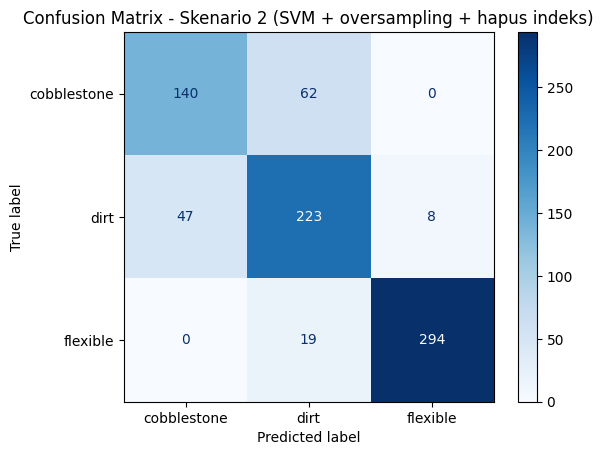

In [ ]:
svm_clf_2 = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42
    )
)

svm_clf_2.fit(X_train_bal, y_train_bal)

y_pred_svm_2 = svm_clf_2.predict(x_test_new)

acc_svm_2 = accuracy_score(y_test_new, y_pred_svm_2)
print("Skenario 2 - SVM (RBF, oversampled train, outlier removed) - Accuracy:", acc_svm_2)

print("\nClassification Report (Skenario 2 - SVM):")
print(classification_report(y_test_new, y_pred_svm_2))

cm2 = confusion_matrix(y_test_new, y_pred_svm_2, labels=svm_clf_2.classes_)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2,
                               display_labels=svm_clf_2.classes_)
disp2.plot(cmap="Blues")
plt.title("Confusion Matrix - Skenario 2 (SVM + oversampling + hapus indeks)")
plt.show()


Skenario 2 - SVM (RBF, oversampled train, outlier removed) - Accuracy: 0.8106060606060606

Classification Report (Skenario 2 - SVM):
              precision    recall  f1-score   support

 cobblestone       0.68      0.63      0.66        65
        dirt       0.72      0.80      0.76        98
    flexible       0.99      0.94      0.96       101

    accuracy                           0.81       264
   macro avg       0.80      0.79      0.79       264
weighted avg       0.81      0.81      0.81       264



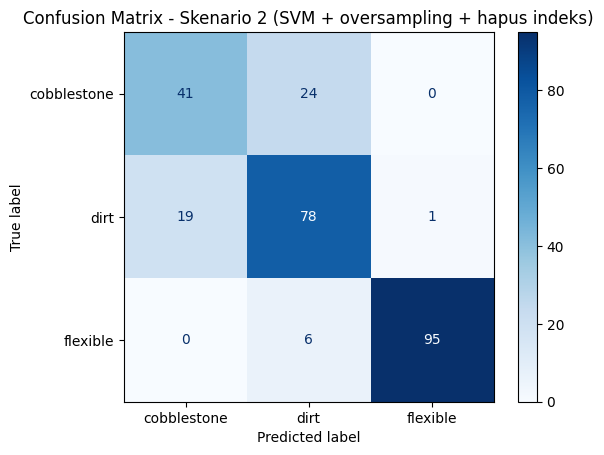

In [81]:
import joblib

svm_clf_2 = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42
    )
)

svm_clf_2.fit(X_train_bal, y_train_bal)
joblib.dump(svm_clf_2, "svm_rbf.pkl")

y_pred_svm_2 = svm_clf_2.predict(X_test)

acc_svm_2 = accuracy_score(y_test, y_pred_svm_2)
print("Skenario 2 - SVM (RBF, oversampled train, outlier removed) - Accuracy:", acc_svm_2)

print("\nClassification Report (Skenario 2 - SVM):")
print(classification_report(y_test, y_pred_svm_2))

cm2 = confusion_matrix(y_test, y_pred_svm_2, labels=svm_clf_2.classes_)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2,
                               display_labels=svm_clf_2.classes_)
disp2.plot(cmap="Blues")
plt.title("Confusion Matrix - Skenario 2 (SVM + oversampling + hapus indeks)")
plt.show()


## Hasil Aplikasi

[Klik di sini untuk membuka aplikasi](https://klasifikasiasphaltpavementtype.streamlit.app/)